<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana6/ProblemaClasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación binaria: predicción de *churn* bancario

## Objetivo de la clase

Construiremos una red neuronal para estimar si un cliente **abandona el banco** (`Exited = 1`) o **permanece** (`Exited = 0`).

Además del modelo, el objetivo importante es aprender un flujo de trabajo correcto para clasificación:

1. separar **train / validation / test**;
2. ajustar el preprocesamiento **solo con train**;
3. entrenar el modelo;
4. escoger hiperparámetros y umbrales usando **validation**;
5. usar **test una sola vez al final** para estimar el desempeño fuera de muestra.

> **Idea clave:** el conjunto de prueba no debe participar en decisiones de modelado. Si escogemos el umbral que maximiza F1 usando `y_test`, entonces el test deja de ser completamente independiente.

## Cambios conceptuales respecto a la versión inicial

- `Exited` representa *churn*: **1 = el cliente salió**, **0 = permaneció**.
- Un desbalance cercano a 80/20 **no obliga** a hacer remuestreo. El *downsampling* elimina información de la clase mayoritaria.
- El preprocesamiento se ajusta únicamente sobre `X_train` para evitar fugas de información (*data leakage*).
- Se crea un conjunto de **validación separado**. El umbral se elige allí y no en test.
- Además de `accuracy`, se estudian **precision, recall, F1, ROC-AUC y PR-AUC**.
- Se mantiene `class_weight` como una opción pedagógica si interesa penalizar más los falsos negativos, pero no se activa por defecto.
- Se usa `Input(...)` en Keras en lugar de pasar `input_shape` directamente a la primera capa `Dense`.

In [1]:
# ==============================
# 1. Librerías y reproducibilidad
# ==============================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [2]:
# ==================================
# 2. Ruta de datos: Colab o local
# ==================================

# En Colab montamos Drive. En ejecución local simplemente usamos una ruta relativa.
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DATA_PATH = Path(
        '/content/drive/MyDrive/IntroCienciaDatos/Semana6/Datos/Churn_Modelling.csv'
    )
else:
    DATA_PATH = Path('Datos/Churn_Modelling.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'No se encontró el archivo en: {DATA_PATH}\n'
        'Modifica DATA_PATH para que apunte a Churn_Modelling.csv.'
    )

print('Archivo:', DATA_PATH)

Mounted at /content/drive
Archivo: /content/drive/MyDrive/IntroCienciaDatos/Semana6/Datos/Churn_Modelling.csv


In [3]:
# ==============================
# 3. Carga e inspección inicial
# ==============================

df = pd.read_csv(DATA_PATH)
print('Dimensiones:', df.shape)
display(df.head())

df.info()

Dimensiones: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Variables que no usaremos como predictores

`RowNumber`, `CustomerId` y `Surname` son identificadores. En principio no describen el comportamiento financiero del cliente y pueden introducir patrones espurios.

> **Comentario para clase:** eliminar una variable no debe hacerse solo porque “parece inútil”. La pregunta correcta es: ¿tendría esta variable información disponible y legítima en el momento real de hacer la predicción?

In [4]:
# Eliminamos identificadores sin modificar el DataFrame de forma difícil de rastrear.
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_model = df.drop(columns=cols_to_drop).copy()

display(df_model.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


,n,proporción
Permanece (0),7963,0.7963
Churn (1),2037,0.2037


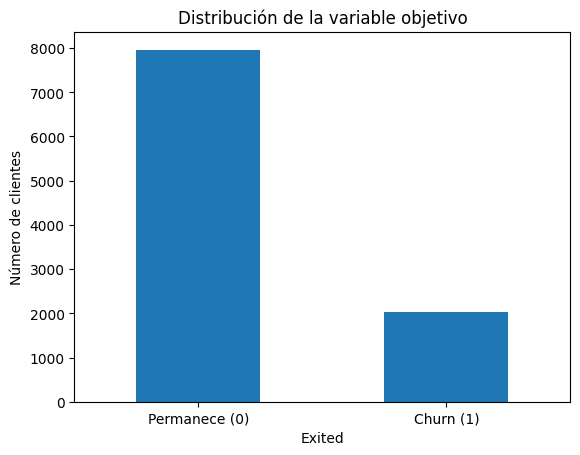

Accuracy de un clasificador que siempre predice la mayoría: 0.796


In [5]:
# =====================================
# 4. Variable objetivo y desbalance
# =====================================

TARGET = 'Exited'

y = df_model[TARGET].astype(int)
X = df_model.drop(columns=TARGET)

counts = y.value_counts().sort_index()
props = y.value_counts(normalize=True).sort_index()

summary = pd.DataFrame({
    'n': counts,
    'proporción': props
})
summary.index = ['Permanece (0)', 'Churn (1)']
display(summary)

ax = counts.plot(kind='bar')
ax.set_xticklabels(['Permanece (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Número de clientes')
ax.set_title('Distribución de la variable objetivo')
plt.show()

# Baseline ingenuo: predecir siempre la clase más frecuente.
majority_accuracy = props.max()
print(f'Accuracy de un clasificador que siempre predice la mayoría: {majority_accuracy:.3f}')

### ¿Hay que balancear obligatoriamente?

No. Si aproximadamente 80 % de los clientes pertenecen a una clase y 20 % a la otra, existe desbalance, pero eso **no significa automáticamente** que debamos eliminar observaciones.

El *downsampling* de la clase mayoritaria tiene dos efectos importantes:

- desperdicia información útil;
- cambia artificialmente la prevalencia que observa el modelo, lo que puede afectar la interpretación/calibración de las probabilidades.

Primero entrenaremos conservando todos los datos. Más adelante dejamos `class_weight` como opción si el objetivo del negocio exige dar mayor importancia al *churn*.

In [6]:
# ======================================
# 5. Separación train / validation / test
# ======================================

# Primero reservamos 20 % para TEST.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

# Del 80 % restante, tomamos 25 % para VALIDATION.
# Resultado total: 60 % train, 20 % validation, 20 % test.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=SEED,
    stratify=y_trainval,
)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

print('\nProporción de churn')
print(f'Train: {y_train.mean():.3f}')
print(f'Val  : {y_val.mean():.3f}')
print(f'Test : {y_test.mean():.3f}')

Train: (6000, 10) (6000,)
Val  : (2000, 10) (2000,)
Test : (2000, 10) (2000,)

Proporción de churn
Train: 0.204
Val  : 0.203
Test : 0.203


## 6. Preprocesamiento sin fuga de información

En la versión inicial se aplicaba `pd.get_dummies(...)` antes de dividir los datos. Eso no utiliza directamente `y`, pero como regla general es mejor que **toda transformación que “aprenda” algo de los datos se ajuste únicamente con train**.

Usaremos:

- `StandardScaler` para variables numéricas;
- `OneHotEncoder` para variables categóricas;
- `handle_unknown='ignore'` para poder transformar categorías que eventualmente aparezcan fuera de train.

> En una red neuronal no es necesario usar `drop_first=True`; la multicolinealidad exacta es una preocupación más directa en modelos lineales que en una red.

In [7]:
# Detectamos automáticamente columnas numéricas y categóricas.
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print('Numéricas   :', numeric_features)
print('Categóricas :', categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
)

# MUY IMPORTANTE: fit solo con train.
X_train_p = preprocessor.fit_transform(X_train).astype('float32')
X_val_p   = preprocessor.transform(X_val).astype('float32')
X_test_p  = preprocessor.transform(X_test).astype('float32')

print('Dimensión después del preprocesamiento:', X_train_p.shape[1])

Numéricas   : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categóricas : ['Geography', 'Gender']
Dimensión después del preprocesamiento: 13


## 7. ¿Usar pesos de clase?

Los pesos de clase permiten aumentar la penalización de errores sobre la clase minoritaria **sin eliminar observaciones**.

No los activamos por defecto porque el modelo debe responder a un objetivo concreto. Si para el banco un falso negativo (no detectar un cliente que va a irse) es mucho más costoso, entonces podría justificarse aumentar su peso.

> **Advertencia:** cambiar pesos de clase modifica la función de pérdida efectiva. Por ello, el valor de la salida sigmoide no debe asumirse automáticamente como una probabilidad perfectamente calibrada.

In [8]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train,
)
class_weight_balanced = dict(zip(classes, weights))
print('Pesos balanceados sugeridos:', class_weight_balanced)

# Cambiar a True si se quiere experimentar con pesos de clase.
USE_CLASS_WEIGHT = False
class_weight_fit = class_weight_balanced if USE_CLASS_WEIGHT else None

Pesos balanceados sugeridos: {np.int64(0): np.float64(0.6280092108017584), np.int64(1): np.float64(2.4529844644317254)}


## 8. Red neuronal

La arquitectura siguiente es deliberadamente sencilla. Tener más capas no garantiza un mejor clasificador, especialmente en datos tabulares pequeños.

La salida tiene una sola neurona con activación sigmoide:

\[
\hat p = P(Y=1\mid X), \qquad 0\leq \hat p\leq 1.
\]

Durante el entrenamiento usaremos `binary_crossentropy`. La métrica `accuracy` es útil, pero **no debe ser la única** cuando las clases están desbalanceadas.

In [9]:
# Limpiamos cualquier modelo previo si la celda se ejecuta varias veces.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model = Sequential([
    Input(shape=(X_train_p.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.20),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
    ],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ======================================
# 9. Entrenamiento con Early Stopping
# ======================================

# Usamos validation_data explícito.
# Así validation conserva la prevalencia original y NO proviene de un conjunto remuestreado.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_p,
    y_train.to_numpy(),
    validation_data=(X_val_p, y_val.to_numpy()),
    epochs=200,
    batch_size=64,
    callbacks=[early_stopping],
    class_weight=class_weight_fit,
    verbose=1,
)

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7670 - loss: 0.5376 - pr_auc: 0.2456 - roc_auc: 0.5749 - val_accuracy: 0.7975 - val_loss: 0.4611 - val_pr_auc: 0.4019 - val_roc_auc: 0.7067
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8023 - loss: 0.4600 - pr_auc: 0.4017 - roc_auc: 0.7083 - val_accuracy: 0.8080 - val_loss: 0.4339 - val_pr_auc: 0.4643 - val_roc_auc: 0.7565
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8105 - loss: 0.4410 - pr_auc: 0.4593 - roc_auc: 0.7469 - val_accuracy: 0.8180 - val_loss: 0.4213 - val_pr_auc: 0.4963 - val_roc_auc: 0.7760
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8178 - loss: 0.4310 - pr_auc: 0.5013 - roc_auc: 0.7621 - val_accuracy: 0.8265 - val_loss: 0.4119 - val_pr_auc: 0.5255 - val_roc_auc: 0.7884
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8248 - loss: 0.4198 - pr_auc: 0.5354 - roc_auc: 0.7761 - val_accuracy: 0.8335 - val_loss: 0.4021 - val_pr_auc: 0.5

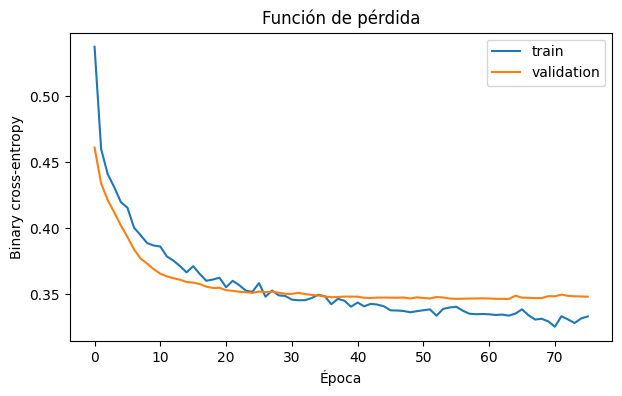

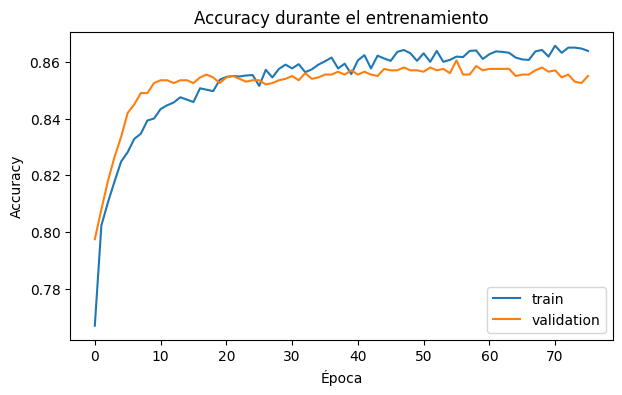

In [11]:
# ======================================
# 10. Curvas de aprendizaje
# ======================================

hist = pd.DataFrame(history.history)

plt.figure(figsize=(7, 4))
plt.plot(hist['loss'], label='train')
plt.plot(hist['val_loss'], label='validation')
plt.xlabel('Época')
plt.ylabel('Binary cross-entropy')
plt.title('Función de pérdida')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hist['accuracy'], label='train')
plt.plot(hist['val_accuracy'], label='validation')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.legend()  # En el notebook original faltaban los paréntesis de plt.legend().
plt.show()

## 11. Probabilidades y métricas independientes del umbral

La red produce probabilidades (o *scores*) continuos. Antes de convertirlos a 0/1 podemos evaluar la capacidad de ordenamiento del modelo:

- **ROC-AUC:** probabilidad de que un positivo reciba un score mayor que un negativo, interpretada de forma equivalente bajo ciertas condiciones;
- **PR-AUC:** resume la curva *precision-recall* y suele ser especialmente informativa cuando la clase positiva es relativamente poco frecuente.
- **Average Precision (AP):** es otra forma muy usada de resumir la curva *precision-recall*. Está estrechamente relacionada con PR-AUC, pero no debe asumirse que ambas implementaciones producen exactamente el mismo número.

Estas métricas no requieren fijar todavía un umbral de clasificación.

In [12]:
# Probabilidades sobre VALIDATION.
y_val_prob = model.predict(X_val_p, verbose=0).ravel()

val_roc_auc = roc_auc_score(y_val, y_val_prob)
val_ap = average_precision_score(y_val, y_val_prob)

print(f'Validation ROC-AUC        : {val_roc_auc:.4f}')
print(f'Validation Average Prec.  : {val_ap:.4f}')

Validation ROC-AUC        : 0.8592
Validation Average Prec.  : 0.6820


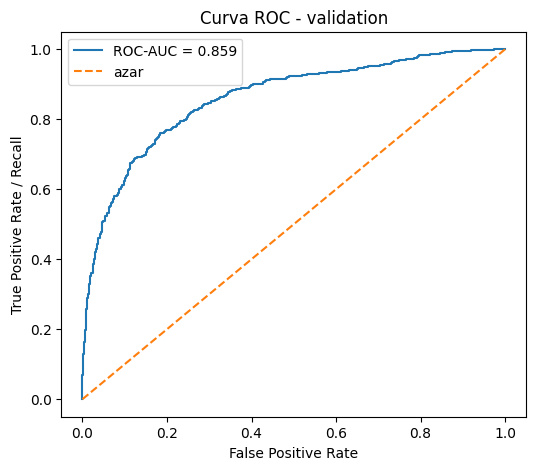

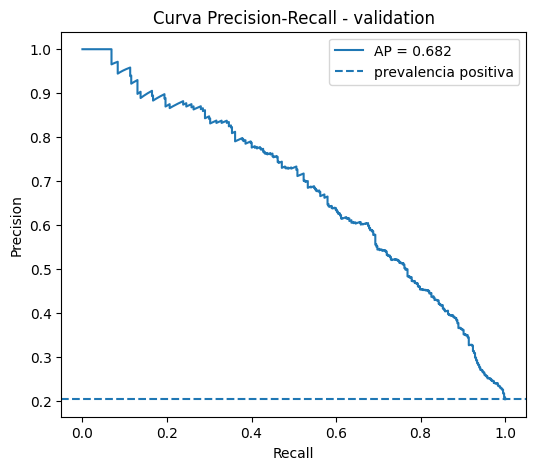

In [13]:
# Curva ROC en validation
fpr, tpr, _ = roc_curve(y_val, y_val_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {val_roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', label='azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('Curva ROC - validation')
plt.legend()
plt.show()

# Curva Precision-Recall en validation
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_val_prob)

plt.figure(figsize=(6, 5))
plt.plot(rec_curve, prec_curve, label=f'AP = {val_ap:.3f}')
plt.axhline(y_val.mean(), linestyle='--', label='prevalencia positiva')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - validation')
plt.legend()
plt.show()

## 12. El umbral no tiene por qué ser 0.5

Para transformar la salida sigmoide en una clase usamos

\[
\hat y =
\begin{cases}
1, & \hat p \ge t,\\
0, & \hat p < t.
\end{cases}
\]

- un umbral **alto** tiende a aumentar *precision* y reducir *recall*;
- un umbral **bajo** tiende a aumentar *recall* y producir más falsos positivos.

El umbral correcto depende del costo real de cada error. Aquí, solo como ejercicio didáctico, escogeremos el umbral que maximiza **F1 en validation**.

> **No usamos test para escogerlo.**

Mejor umbral según F1 en validation: 0.2823
F1 correspondiente               : 0.6381


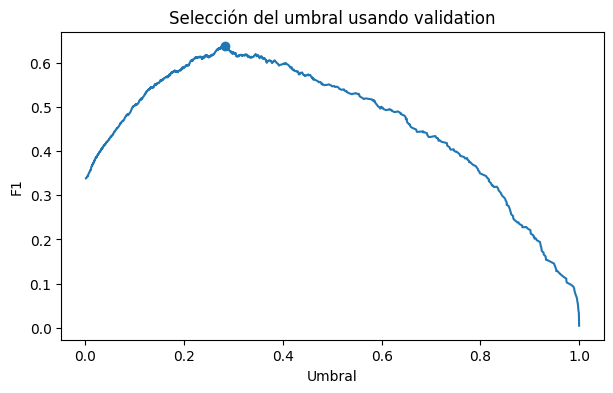

In [14]:
# Calculamos F1 exactamente sobre los umbrales generados por la curva PR.
prec_v, rec_v, thresholds_v = precision_recall_curve(y_val, y_val_prob)

# precision y recall tienen un elemento más que thresholds.
prec_for_t = prec_v[:-1]
rec_for_t = rec_v[:-1]

f1_for_t = 2 * prec_for_t * rec_for_t / (prec_for_t + rec_for_t + 1e-12)

best_idx = np.argmax(f1_for_t)
best_threshold = float(thresholds_v[best_idx])
best_val_f1 = float(f1_for_t[best_idx])

print(f'Mejor umbral según F1 en validation: {best_threshold:.4f}')
print(f'F1 correspondiente               : {best_val_f1:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds_v, f1_for_t)
plt.scatter([best_threshold], [best_val_f1], zorder=3)
plt.xlabel('Umbral')
plt.ylabel('F1')
plt.title('Selección del umbral usando validation')
plt.show()

In [15]:
# Función auxiliar para comparar métricas a un umbral dado.
def metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return pd.Series({
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    })

comparison_val = pd.DataFrame([
    metrics_at_threshold(y_val, y_val_prob, 0.50),
    metrics_at_threshold(y_val, y_val_prob, best_threshold),
])

display(comparison_val)

,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.500000,0.8575,0.695609,0.774775,0.422604,0.546900
1,0.282266,0.8440,0.781341,0.604396,0.675676,0.638051


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.1,0.633,0.737,0.347,0.912,0.503
1,0.2,0.778,0.779,0.473,0.779,0.589
2,0.3,0.844,0.764,0.614,0.629,0.621
3,0.4,0.860,0.730,0.724,0.509,0.597
4,0.5,0.858,0.696,0.775,0.423,0.547
5,0.6,0.852,0.669,0.811,0.359,0.497
6,0.7,0.845,0.638,0.849,0.290,0.432
7,0.8,0.834,0.604,0.871,0.216,0.346
8,0.9,0.820,0.561,0.927,0.125,0.221


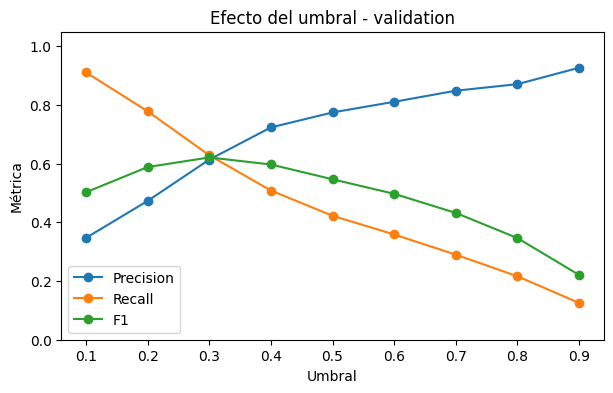

In [16]:
# Tabla pedagógica: cómo cambian las métricas al mover el umbral.
# La construimos sobre VALIDATION, no sobre TEST.
threshold_grid = np.arange(0.1, 1.0, 0.1)

threshold_table = pd.DataFrame([
    metrics_at_threshold(y_val, y_val_prob, t)
    for t in threshold_grid
])

display(threshold_table.round(3))

plt.figure(figsize=(7, 4))
plt.plot(threshold_table['threshold'], threshold_table['precision'], marker='o', label='Precision')
plt.plot(threshold_table['threshold'], threshold_table['recall'], marker='o', label='Recall')
plt.plot(threshold_table['threshold'], threshold_table['f1'], marker='o', label='F1')
plt.xlabel('Umbral')
plt.ylabel('Métrica')
plt.title('Efecto del umbral - validation')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

# 13. Evaluación final sobre TEST

A partir de este punto consideramos cerradas las decisiones principales del modelo.

**Regla pedagógica:** después de mirar estas métricas de test no deberíamos seguir cambiando arquitectura, pesos o umbral basándonos en estos mismos resultados. Si lo hacemos repetidamente, el test termina funcionando como otro conjunto de validación.

In [17]:
# TEST se usa ahora por primera vez para la evaluación final.
y_test_prob = model.predict(X_test_p, verbose=0).ravel()

test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_ap = average_precision_score(y_test, y_test_prob)

print(f'Test ROC-AUC       : {test_roc_auc:.4f}')
print(f'Test Average Prec. : {test_ap:.4f}')

comparison_test = pd.DataFrame([
    metrics_at_threshold(y_test, y_test_prob, 0.50),
    metrics_at_threshold(y_test, y_test_prob, best_threshold),
])
comparison_test.index = ['umbral 0.50', 'umbral elegido en validation']
display(comparison_test)

Test ROC-AUC       : 0.8603
Test Average Prec. : 0.7030


,threshold,accuracy,balanced_accuracy,precision,recall,f1
umbral 0.50,0.500000,0.8625,0.705150,0.792035,0.439803,0.565561
umbral elegido en validation,0.282266,0.8320,0.769235,0.575693,0.663391,0.616438


In [18]:
# Reporte final usando el umbral escogido en VALIDATION.
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(classification_report(
    y_test,
    y_test_pred,
    target_names=['No churn', 'Churn'],
    digits=3,
    zero_division=0,
))

              precision    recall  f1-score   support

    No churn      0.911     0.875     0.892      1593
       Churn      0.576     0.663     0.616       407

    accuracy                          0.832      2000
   macro avg      0.743     0.769     0.754      2000
weighted avg      0.842     0.832     0.836      2000



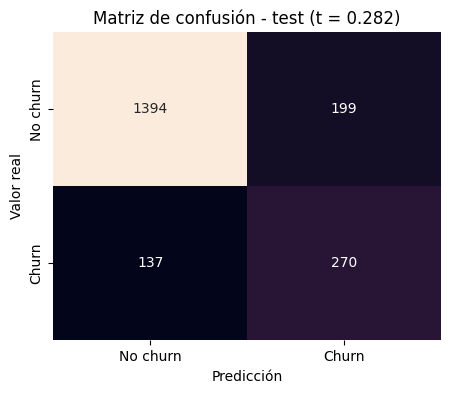

TN: 1394 | FP: 199 | FN: 137 | TP: 270


In [19]:
# Matriz de confusión final.
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=['No churn', 'Churn'],
    yticklabels=['No churn', 'Churn'],
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title(f'Matriz de confusión - test (t = {best_threshold:.3f})')
plt.show()

# Descomposición para discutir los cuatro casos.
tn, fp, fn, tp = cm.ravel()
print('TN:', tn, '| FP:', fp, '| FN:', fn, '| TP:', tp)

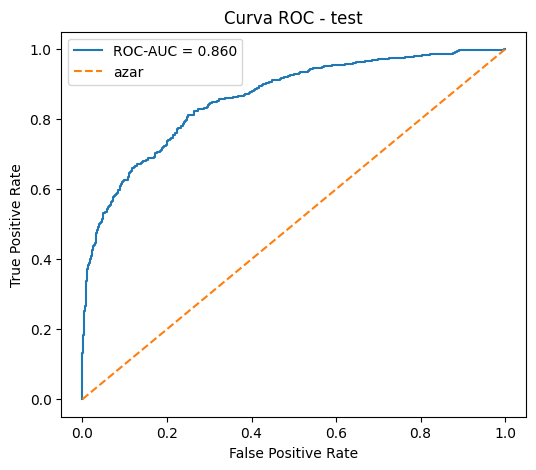

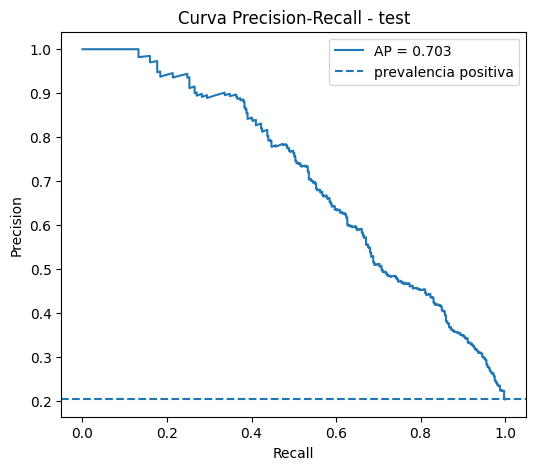

In [20]:
# Curvas finales sobre test: resumen descriptivo del modelo ya cerrado.
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
prec_test, rec_test, _ = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_test, tpr_test, label=f'ROC-AUC = {test_roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', label='azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - test')
plt.legend()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(rec_test, prec_test, label=f'AP = {test_ap:.3f}')
plt.axhline(y_test.mean(), linestyle='--', label='prevalencia positiva')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - test')
plt.legend()
plt.show()

## 14. Predicción de un cliente individual

Es preferible seleccionar la fila original y aplicar **el mismo preprocesador ya ajustado**. De esta manera vemos claramente el flujo que usaríamos con un cliente nuevo en producción.

In [21]:
idx = 10
cliente = X_test.iloc[[idx]]
cliente_p = preprocessor.transform(cliente).astype('float32')

prob_churn = float(model.predict(cliente_p, verbose=0).ravel()[0])
pred_churn = int(prob_churn >= best_threshold)
real = int(y_test.iloc[idx])

print(f'Probabilidad estimada de churn : {prob_churn:.4f}')
print(f'Umbral usado                   : {best_threshold:.4f}')
print(f'Predicción                     : {pred_churn}')
print(f'Valor real                     : {real}')

display(cliente)

Probabilidad estimada de churn : 0.5148
Umbral usado                   : 0.2823
Predicción                     : 1
Valor real                     : 1


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7068,699,Germany,Female,54,3,111009.32,1,1,1,155905.79


# 15. Comparación con un modelo base: regresión logística

Una red neuronal no debería evaluarse en el vacío. Para datos tabulares relativamente pequeños conviene comparar contra un modelo simple.

Si la regresión logística alcanza un desempeño parecido, eso es un resultado importante: quizá la complejidad adicional de la red no esté aportando demasiado.

In [22]:
logreg = LogisticRegression(max_iter=2000, random_state=SEED)
logreg.fit(X_train_p, y_train)

logreg_val_prob = logreg.predict_proba(X_val_p)[:, 1]
logreg_test_prob = logreg.predict_proba(X_test_p)[:, 1]

benchmark = pd.DataFrame({
    'modelo': ['Red neuronal', 'Regresión logística'],
    'val_ROC_AUC': [
        roc_auc_score(y_val, y_val_prob),
        roc_auc_score(y_val, logreg_val_prob),
    ],
    'val_AP': [
        average_precision_score(y_val, y_val_prob),
        average_precision_score(y_val, logreg_val_prob),
    ],
    'test_ROC_AUC': [
        roc_auc_score(y_test, y_test_prob),
        roc_auc_score(y_test, logreg_test_prob),
    ],
    'test_AP': [
        average_precision_score(y_test, y_test_prob),
        average_precision_score(y_test, logreg_test_prob),
    ],
})

display(benchmark)

,modelo,val_ROC_AUC,val_AP,test_ROC_AUC,test_AP
0,Red neuronal,0.859184,0.682045,0.860330,0.702977
1,Regresión logística,0.756636,0.463021,0.775208,0.480620


# 16. Preguntas para discutir en clase

1. ¿Por qué una `accuracy` de 80 % podría ser poco impresionante en este problema?
2. ¿Qué significa un falso negativo en términos de *churn*?
3. ¿Qué pasaría con *precision* y *recall* si aumentamos el umbral de 0.5 a 0.8?
4. ¿Por qué no debemos elegir el mejor umbral usando el conjunto de test?
5. ¿Cuándo tendría sentido usar `class_weight`?
6. ¿Por qué ROC-AUC y PR-AUC responden preguntas diferentes?
7. Si la regresión logística y la red tienen resultados parecidos, ¿cuál escogeríamos y por qué?
8. ¿Qué información del negocio necesitaríamos para elegir un umbral mejor que “el que maximiza F1”?